In [ ]:
!python -c "import cv2; print(cv2.__version__)"

5.0.0


In [ ]:
import cv2
video_path = "./examples/sample_demo_1.mp4"

# 捕获视频对象
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    cap.release()
    raise RuntimeError("Video not found")


# 获取视频的基本信息
fps = cap.get(cv2.CAP_PROP_FPS) # 帧率
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) # 总帧数
# 分辨率
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))


print("Frame count: ", frame_count)
print("Width: ", width)
print("Height: ", height)
print("FPS: ", fps)

if fps > 0:
    print(f'估算时长：{frame_count / fps:.2f}秒')

# 释放视频资源
cap.release()


Frame count:  243
Width:  640
Height:  360
FPS:  25.0
估算时长：9.72秒


读取视频的第一帧，并显示出来

数据类型: <class 'numpy.ndarray'>
形状: (360, 640, 3)
像素储存类型: uint8


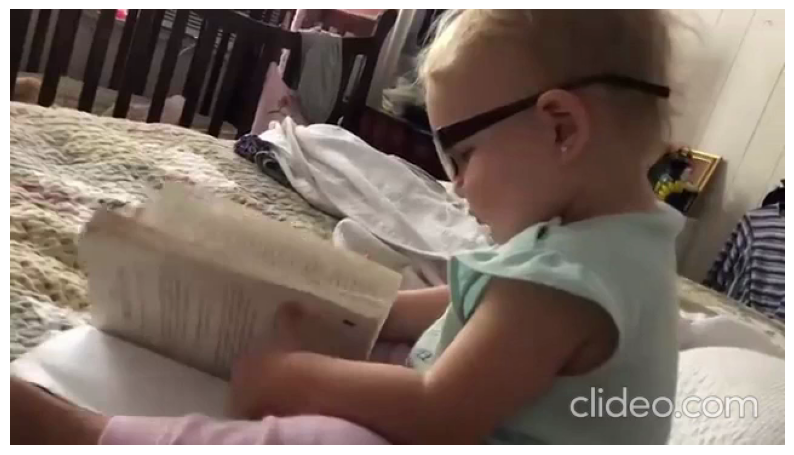

In [ ]:
import matplotlib.pyplot as plt


cap = cv2.VideoCapture(video_path)

# 读取一帧
success,frame = cap.read()

if not success:
    raise RuntimeError("读取第一帧失败")

print("数据类型:",type(frame))
print("形状:",frame.shape) # BGR (H,W,C)
print("像素储存类型:",frame.dtype)

# OpenCV 默认采用 BGR 顺序，需要转换为 RGB 才能正常显示
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,6))
plt.imshow(frame_rgb)
plt.axis('off')
plt.show()


## 均匀抽帧
在视频的开头到结尾，均匀选出 8 帧

抽取的帧编号: [  0  34  69 103 138 172 207 242]
实际抽取的帧数 8


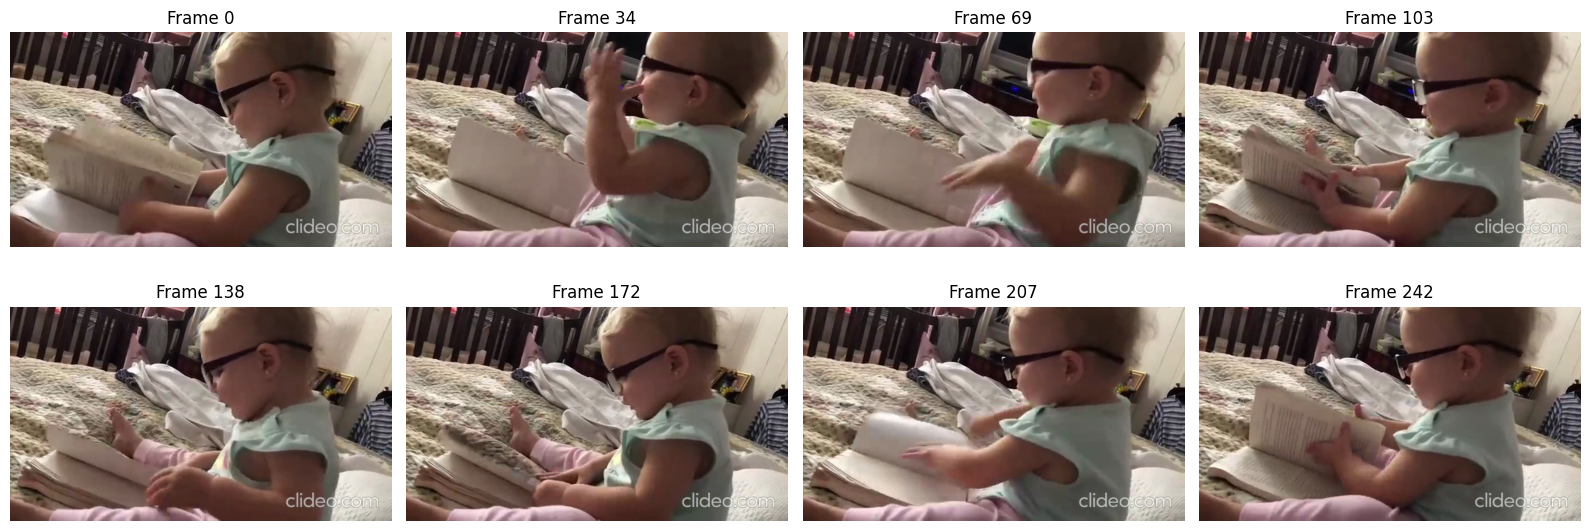

In [ ]:
import numpy as np

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    cap.release()
    raise RuntimeError("Video not found")


frames = []

try:
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        raise RuntimeError("无法获取有效的帧数")

    # 视频如果不足八帧，就读取所有帧
    num_sample = min(8, total_frames)

    frame_indices =np.linspace(
        0,total_frames - 1,num_sample,dtype=int
    )
    for index in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, index) # 将读取位置移动到指定帧

        success,frame = cap.read()
        if not success:
            raise RuntimeError(f"读取到 {index} 帧时失败")

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame_rgb)

finally:
    cap.release()

print("抽取的帧编号:",frame_indices)
print("实际抽取的帧数",len(frames))


# 可视化图片，将图片排列成两行四列

fig,axes = plt.subplots(2,4,figsize=(16,6))

for ax in axes.flat:
    ax.axis('off')

for ax,index,frame in zip(axes.flat,frame_indices,frames):
    ax.imshow(frame)
    ax.set_title(f'Frame {index}')

plt.tight_layout()
plt.show()

将上面八张图片大保证一个模型常用的张量模型，形状为 $(T,C,H,W) = (8,3,224,224)$

In [ ]:
import torch
resized_frames =[
    cv2.resize(frame,(224,224))
    for frame in frames
]

video_array = np.stack(resized_frames,axis=0)
print("Numpy 数组",video_array.shape)

# 将每个像素的数据类型转换为浮点张量,将像素值缩放到 0～1 之间
video_tensor = torch.from_numpy(video_array).float() / 255.0

# 转换形状，将 Channel 移到前面 变为 (T,C,H,W)
video_tensor = video_tensor.permute(0,3,1,2)

print("Tensor 数组:",video_tensor.shape)
print("数据类型:",video_tensor.dtype)
# 再进一步，我们还可以添加 Batch 这个维度
video_batch = video_tensor.unsqueeze(0)
print("Tensor 带 Batch 维度:",video_batch.shape)

Numpy 数组 (8, 224, 224, 3)
Tensor 数组: torch.Size([8, 3, 224, 224])
数据类型: torch.float32
Tensor 带 Batch 维度: torch.Size([1, 8, 3, 224, 224])


## 进入语言模型的输入准备

真正使用 Owl3 时，图片缩放、归一化和文字编码会交给它的 processor（输入处理器），我们不直接把刚才的五维张量传进去。

输入流程大概是：
RGB 图片列表＋文字指令 → processor → 模型需要的张量 → model.generate → 输出文字

In [ ]:
from PIL import Image

# 使用前面已经抽取的 8 帧作为输入
# 不使用缩放、归一化 的 video_tensor 也就是说

video_frames = [
    Image.fromarray(frame)
    for frame in frames
]

# 给模型提示词
prompt = (
    "Describe what happens in this video,"
    "including the main actions and their order."
)

# 按照 Owl3 格式输入
messages = [
    {
        "role": "user",
        "content": "<|video|>\n" + prompt,
    },
    {
        "role": "assistant",
        "content": "",
    },
